# One-Step Fall Detection — FCOS Model Testing
**COS30018 – Intelligent Systems | Assignment Topic 3**

This notebook tests the already-trained FCOS + MobileNetV3 fall detection model.
No training is done here — just load the best weights and evaluate.

| Class ID | Label |
|----------|-------|
| 0 | fall detected |
| 1 | walk |
| 2 | sit |

---
## 1. Imports

In [1]:
import random
import warnings
import platform
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.transforms import functional as TF
from torchvision import models

warnings.filterwarnings('ignore')
random.seed(42)
print('Imports OK')

Imports OK


---
## 2. Configuration — Edit Paths Here

In [2]:
# ── Path to trained weights ───────────────────────────────────────────────────
BEST_WEIGHTS = Path('./fcos_fall_detector.pth')

# ── Dataset paths ─────────────────────────────────────────────────────────────
DATASET_ROOT = Path('../dataset/fall_dataset')
TEST_IMG_DIR = DATASET_ROOT / 'images' / 'test'
TEST_LBL_DIR = DATASET_ROOT / 'labels' / 'test'

# ── Model & inference settings ────────────────────────────────────────────────
CLASS_NAMES    = ['fall detected', 'walk', 'sit']
IMG_SIZE       = 224
STRIDE         = 16
NUM_CLASSES    = 3
CONF_THRESHOLD = 0.25
NMS_THRESHOLD  = 0.40
IOU_THRESHOLD  = 0.50     # IoU threshold for a detection to count as correct

# ── Low-light filename prefixes (update to match your filenames) ──────────────
LOW_LIGHT_PREFIXES = ('fall_night', 'low_light_walk', 'sit_lowlight')

# ── Box colours (matplotlib named colours) ────────────────────────────────────
BOX_COLORS = {
    'fall detected': '#e74c3c',
    'walk'         : '#3498db',
    'sit'          : '#2ecc71',
}

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FEAT_H     = IMG_SIZE // STRIDE
FEAT_W     = IMG_SIZE // STRIDE

assert BEST_WEIGHTS.exists(), f'Weights not found: {BEST_WEIGHTS}'
print(f'Model weights : {BEST_WEIGHTS}')
print(f'Test images   : {TEST_IMG_DIR}')
print(f'Device        : {DEVICE}')
print(f'Feature map   : {FEAT_H}×{FEAT_W}')

Model weights : fcos_fall_detector.pth
Test images   : ..\dataset\fall_dataset\images\test
Device        : cpu
Feature map   : 14×14


---
## 3. Re-declare Model Architecture & Load Weights

In [3]:
# ── Architecture must match what was used during training ─────────────────────

class LetterboxResize:
    def __init__(self, size):
        self.size = size
    def __call__(self, img):
        W, H   = img.size
        scale  = self.size / max(W, H)
        new_W, new_H = int(W*scale), int(H*scale)
        img    = TF.resize(img, (new_H, new_W))
        pl = (self.size-new_W)//2; pt = (self.size-new_H)//2
        pr = self.size-new_W-pl;   pb = self.size-new_H-pt
        return TF.pad(img, (pl, pt, pr, pb), fill=114)


class MobileNetV3Backbone(nn.Module):
    def __init__(self, freeze_early=False):
        super().__init__()
        mob   = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )
        dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
        n_blocks = len(mob.features)
        cut_idx  = n_blocks
        with torch.no_grad():
            for n in range(1, n_blocks+1):
                out = nn.Sequential(*list(mob.features.children())[:n])(dummy)
                fh, fw = out.shape[2], out.shape[3]
                if fh == FEAT_H and fw == FEAT_W:
                    cut_idx = n; break
                if fh < FEAT_H:
                    cut_idx = max(n-1, 1)
                    out = nn.Sequential(*list(mob.features.children())[:cut_idx])(dummy)
                    break
        self.features     = nn.Sequential(*list(mob.features.children())[:cut_idx])
        self.out_channels = out.shape[1]
    def forward(self, x):
        return self.features(x)


class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)


class FCOSHead(nn.Module):
    def __init__(self, in_channels=96, num_classes=3,
                 tower_channels=128, num_tower_layers=4):
        super().__init__()
        tower = [ConvBNReLU(in_channels, tower_channels)]
        for _ in range(num_tower_layers-1):
            tower.append(ConvBNReLU(tower_channels, tower_channels))
        self.tower      = nn.Sequential(*tower)
        self.cls_branch = nn.Conv2d(tower_channels, num_classes, 1)
        self.reg_branch = nn.Conv2d(tower_channels, 4, 1)
        self.ctr_branch = nn.Conv2d(tower_channels, 1, 1)
        self.scale      = nn.Parameter(torch.ones(1))
    def forward(self, x):
        feat       = self.tower(x)
        cls_logits = self.cls_branch(feat)
        reg_pred   = torch.exp(self.scale * self.reg_branch(feat))
        ctr_logits = self.ctr_branch(feat)
        return cls_logits, reg_pred, ctr_logits


class FCOSDetector(nn.Module):
    def __init__(self, num_classes=3, freeze_early=False,
                 tower_channels=128, num_tower_layers=4):
        super().__init__()
        self.backbone = MobileNetV3Backbone(freeze_early=freeze_early)
        self.head     = FCOSHead(
            in_channels      = self.backbone.out_channels,
            num_classes      = num_classes,
            tower_channels   = tower_channels,
            num_tower_layers = num_tower_layers
        )
    def forward(self, x):
        return self.head(self.backbone(x))


# ── Load weights ──────────────────────────────────────────────────────────────
model = FCOSDetector(num_classes=NUM_CLASSES, freeze_early=False)
model.load_state_dict(torch.load(BEST_WEIGHTS, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded  : {BEST_WEIGHTS.name}')
print(f'Classes       : { {i: n for i, n in enumerate(CLASS_NAMES)} }')
print(f'Parameters    : {n_params:,}')

Model loaded  : fcos_fall_detector.pth
Classes       : {0: 'fall detected', 1: 'walk', 2: 'sit'}
Parameters    : 514,729


---
## 4. Inference Helpers

In [4]:
INFER_TF = T.Compose([
    LetterboxResize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def compute_iou(box1, box2):
    ix1 = max(box1[0], box2[0]); iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2]); iy2 = min(box1[3], box2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    a1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    a2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    return inter / (a1 + a2 - inter + 1e-6)


def decode_fcos(cls_logits, reg_pred, ctr_logits,
                conf_thresh=0.25, nms_thresh=0.40):
    C, H, W   = cls_logits.shape
    cls_probs = torch.sigmoid(cls_logits)
    ctr_score = torch.sigmoid(ctr_logits[0])
    boxes_all = []
    for row in range(H):
        for col in range(W):
            cls_score, cls_id = cls_probs[:, row, col].max(dim=0)
            score = cls_score.item() * ctr_score[row, col].item()
            if score < conf_thresh:
                continue
            px = (col + 0.5) * STRIDE
            py = (row + 0.5) * STRIDE
            l, t, r, b = reg_pred[:, row, col].tolist()
            x1 = max(0.0, (px-l) / IMG_SIZE)
            y1 = max(0.0, (py-t) / IMG_SIZE)
            x2 = min(1.0, (px+r) / IMG_SIZE)
            y2 = min(1.0, (py+b) / IMG_SIZE)
            if x2 <= x1 or y2 <= y1:
                continue
            boxes_all.append({'box': [x1,y1,x2,y2],
                               'class': cls_id.item(),
                               'score': score})
    boxes_all.sort(key=lambda x: -x['score'])
    kept = []
    while boxes_all:
        best = boxes_all.pop(0)
        kept.append(best)
        boxes_all = [b for b in boxes_all
                     if compute_iou(best['box'], b['box']) < nms_thresh]
    return kept


def predict_image(img_path, conf=CONF_THRESHOLD):
    """Run FCOS inference on a single image path. Returns list of detections."""
    img_pil = Image.open(img_path).convert('RGB')
    tensor  = INFER_TF(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        cls_out, reg_out, ctr_out = model(tensor)
    return decode_fcos(
        cls_out[0].cpu(), reg_out[0].cpu(), ctr_out[0].cpu(),
        conf_thresh=conf, nms_thresh=NMS_THRESHOLD
    )


def load_gt(img_path):
    """Load ground-truth boxes for an image from the test label directory."""
    txt  = TEST_LBL_DIR / (Path(img_path).stem + '.txt')
    gts  = []
    if txt.exists():
        for line in open(txt):
            p = line.strip().split()
            if len(p) < 5:
                continue
            cls = int(p[0])
            cx, cy, bw, bh = map(float, p[1:5])
            gts.append({'class': cls,
                         'box'  : [cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2]})
    return gts


print('Inference helpers ready.')

Inference helpers ready.


---
## 5. Collect Test Images & Split Normal / Low-Light

In [5]:
all_imgs = sorted(
    list(TEST_IMG_DIR.glob('*.jpg')) +
    list(TEST_IMG_DIR.glob('*.png'))
)

lowlight_imgs = [f for f in all_imgs
                 if f.stem.lower().startswith(LOW_LIGHT_PREFIXES)]
normal_imgs   = [f for f in all_imgs if f not in lowlight_imgs]

print(f'Total test images : {len(all_imgs)}')
print(f'Normal images     : {len(normal_imgs)}')
print(f'Low-light images  : {len(lowlight_imgs)}')

Total test images : 183
Normal images     : 151
Low-light images  : 32


---
## 6. Overall Test Set Evaluation
Runs inference on every test image and computes mAP, precision, recall per class.

In [6]:
def evaluate_test_set(img_list, iou_thresholds=None):
    """Compute mAP@50, mAP@50-95, precision, recall over img_list."""
    if iou_thresholds is None:
        iou_thresholds = [0.5]

    ap_table   = defaultdict(list)
    all_preds  = []
    all_gts    = []

    print(f'Running inference on {len(img_list)} images...')
    for img_path in img_list:
        preds = predict_image(img_path)
        gts   = load_gt(img_path)
        all_preds.append(preds)
        all_gts.append(gts)

    for iou_thresh in iou_thresholds:
        cls_preds = defaultdict(list)
        cls_n_gt  = defaultdict(int)
        for preds, gts in zip(all_preds, all_gts):
            for gt in gts:
                cls_n_gt[gt['class']] += 1
            matched = set()
            for pred in sorted(preds, key=lambda x: -x['score']):
                best_iou, best_j = 0.0, -1
                for j, gt in enumerate(gts):
                    if gt['class'] != pred['class'] or j in matched:
                        continue
                    iou = compute_iou(pred['box'], gt['box'])
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                tp = int(best_iou >= iou_thresh and best_j >= 0)
                if tp:
                    matched.add(best_j)
                cls_preds[pred['class']].append((pred['score'], tp))
        for cls_id in range(NUM_CLASSES):
            n_gt  = cls_n_gt[cls_id]
            pairs = sorted(cls_preds[cls_id], key=lambda x: -x[0])
            if n_gt == 0 or not pairs:
                ap_table[cls_id].append(0.0); continue
            tp_cum = np.cumsum([p[1] for p in pairs])
            fp_cum = np.cumsum([1-p[1] for p in pairs])
            prec   = tp_cum / (tp_cum + fp_cum + 1e-6)
            rec    = tp_cum / (n_gt + 1e-6)
            ap = sum(
                (prec[rec >= t].max() if (rec >= t).any() else 0)
                for t in np.linspace(0, 1, 101)
            ) / 101
            ap_table[cls_id].append(ap)

    ap50   = [float(np.mean(ap_table[c][:1]))  for c in range(NUM_CLASSES)]
    ap5095 = [float(np.mean(ap_table[c]))       for c in range(NUM_CLASSES)]
    mAP50   = float(np.mean(ap50))
    mAP5095 = float(np.mean(ap5095))

    # Precision & Recall at conf_thresh
    tp_total = fp_total = fn_total = 0
    for preds, gts in zip(all_preds, all_gts):
        matched = set()
        for pred in preds:
            best_iou, best_j = 0.0, -1
            for j, gt in enumerate(gts):
                if j in matched: continue
                iou = compute_iou(pred['box'], gt['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= IOU_THRESHOLD:
                matched.add(best_j); tp_total += 1
            else:
                fp_total += 1
        fn_total += len(gts) - len(matched)

    precision = tp_total / (tp_total + fp_total + 1e-6)
    recall    = tp_total / (tp_total + fn_total + 1e-6)

    return {
        'ap50'     : ap50,
        'ap5095'   : ap5095,
        'mAP50'    : mAP50,
        'mAP5095'  : mAP5095,
        'precision': precision,
        'recall'   : recall,
        'all_preds': all_preds,
        'all_gts'  : all_gts,
    }


# Run on full test set (ap50 + ap5095)
results = evaluate_test_set(
    all_imgs,
    iou_thresholds=np.arange(0.5, 1.0, 0.05).tolist()
)

print('\n' + '='*45)
print('       OVERALL TEST SET METRICS')
print('='*45)
print(f'  mAP@50       : {results["mAP50"]:.4f}')
print(f'  mAP@50-95    : {results["mAP5095"]:.4f}')
print(f'  Precision    : {results["precision"]:.4f}')
print(f'  Recall       : {results["recall"]:.4f}')
print('='*45)
print('\n  PER-CLASS AP@50')
print('-'*35)
for name, ap in zip(CLASS_NAMES, results['ap50']):
    bar = '█' * int(ap * 30)
    print(f'  {name:<16} {ap:.4f}  {bar}')

Running inference on 183 images...

       OVERALL TEST SET METRICS
  mAP@50       : 0.1330
  mAP@50-95    : 0.0384
  Precision    : 0.5210
  Recall       : 0.2780

  PER-CLASS AP@50
-----------------------------------
  fall detected    0.3336  ██████████
  walk             0.0495  █
  sit              0.0158  


---
## 7. IoU & mAP Analysis

   IoU & mAP Results — One-Step FCOS
  Class               AP@50   AP@50-95
-------------------------------------------------------
  fall detected      0.3336     0.0794
  walk               0.0495     0.0300
  sit                0.0158     0.0060
-------------------------------------------------------
  mAP (mean)         0.1330     0.0384

  Interpretation:
  AP@50    = detection counted correct if IoU ≥ 0.50
  AP@50-95 = stricter — averaged over IoU 0.50 to 0.95
  Drop from AP@50 → AP@50-95 shows bounding box precision


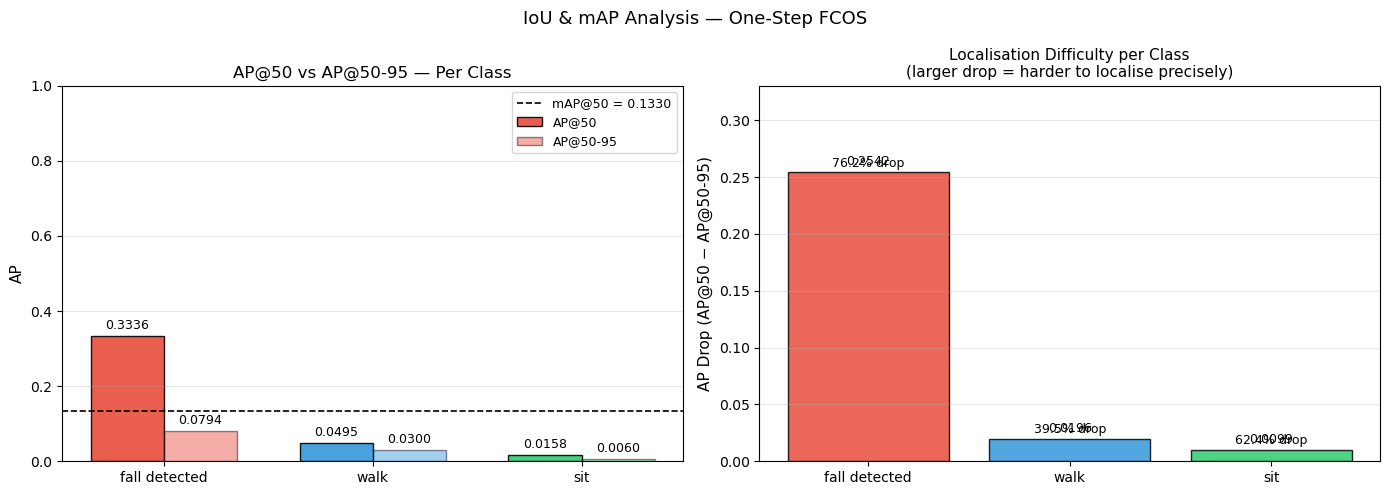

In [7]:
ap50   = results['ap50']
ap5095 = results['ap5095']
colors = ['#e74c3c', '#3498db', '#2ecc71']

# ── Table ─────────────────────────────────────────────────────────────────────
print('='*55)
print('   IoU & mAP Results — One-Step FCOS')
print('='*55)
print(f"  {'Class':<16} {'AP@50':>8} {'AP@50-95':>10}")
print('-'*55)
for name, a50, a5095 in zip(CLASS_NAMES, ap50, ap5095):
    print(f"  {name:<16} {a50:>8.4f} {a5095:>10.4f}")
print('-'*55)
print(f"  {'mAP (mean)':<16} {results['mAP50']:>8.4f} {results['mAP5095']:>10.4f}")
print('='*55)
print(f"\n  Interpretation:")
print(f"  AP@50    = detection counted correct if IoU ≥ 0.50")
print(f"  AP@50-95 = stricter — averaged over IoU 0.50 to 0.95")
print(f"  Drop from AP@50 → AP@50-95 shows bounding box precision")

# ── Plot 1: AP@50 vs AP@50-95 per class ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x  = np.arange(len(CLASS_NAMES))
w  = 0.35
b1 = ax.bar(x-w/2, ap50,   w, label='AP@50',    color=colors, edgecolor='black', alpha=0.9)
b2 = ax.bar(x+w/2, ap5095, w, label='AP@50-95', color=colors, edgecolor='black', alpha=0.45)
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=10)
ax.set_ylabel('AP', fontsize=11)
ax.set_title('AP@50 vs AP@50-95 — Per Class', fontsize=12)
ax.set_ylim(0, 1.0)
ax.axhline(y=results['mAP50'], color='black', linestyle='--',
           linewidth=1.2, label=f'mAP@50 = {results["mAP50"]:.4f}')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: AP drop (localisation difficulty) ─────────────────────────────────
ax2  = axes[1]
drop = np.array(ap50) - np.array(ap5095)
bars = ax2.bar(CLASS_NAMES, drop, color=colors, edgecolor='black', alpha=0.85)
ax2.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax2.set_ylabel('AP Drop (AP@50 − AP@50-95)', fontsize=11)
ax2.set_title('Localisation Difficulty per Class\n(larger drop = harder to localise precisely)', fontsize=11)
ax2.set_ylim(0, max(drop) * 1.3 if max(drop) > 0 else 0.1)
ax2.grid(axis='y', alpha=0.3)
for i, (d, a) in enumerate(zip(drop, ap50)):
    pct = d / a * 100 if a > 0 else 0
    ax2.text(i, d + 0.005, f'{pct:.1f}% drop',
             ha='center', fontsize=9, color='black')

plt.suptitle('IoU & mAP Analysis — One-Step FCOS', fontsize=13)
plt.tight_layout()
plt.savefig('test_iou_map_analysis.png', dpi=150)
plt.show()

---
## 8. Per-Class AP@50 Bar Chart

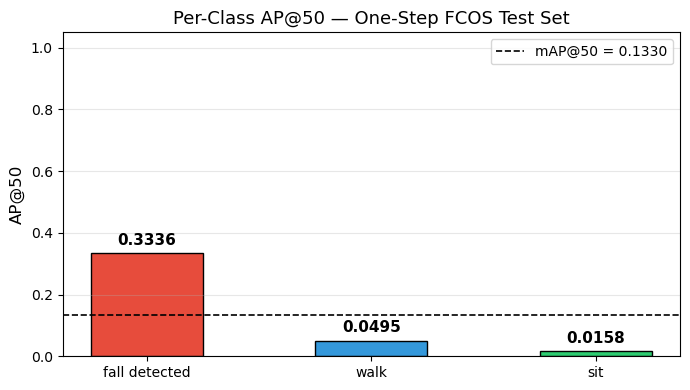

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES, ap50, color=colors, edgecolor='black', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('AP@50', fontsize=12)
ax.set_title('Per-Class AP@50 — One-Step FCOS Test Set', fontsize=13)
ax.axhline(y=results['mAP50'], color='black', linestyle='--',
           linewidth=1.2, label=f'mAP@50 = {results["mAP50"]:.4f}')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('test_per_class_ap50.png', dpi=150)
plt.show()

---
## 9. Confusion Matrix

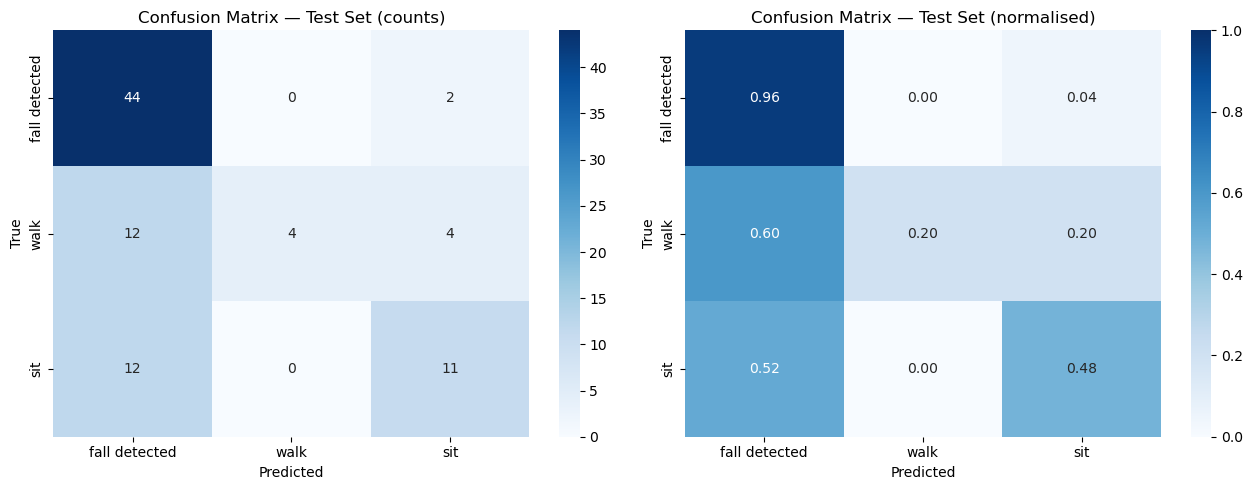

Saved to test_confusion_matrix.png
               precision    recall  f1-score   support

fall detected       0.65      0.96      0.77        46
         walk       1.00      0.20      0.33        20
          sit       0.65      0.48      0.55        23

     accuracy                           0.66        89
    macro avg       0.76      0.54      0.55        89
 weighted avg       0.73      0.66      0.62        89



In [9]:
# Build matched (y_true, y_pred) pairs from test set predictions
y_true, y_pred = [], []
for preds, gts in zip(results['all_preds'], results['all_gts']):
    matched = set()
    for pred in sorted(preds, key=lambda x: -x['score']):
        best_iou, best_j = 0.0, -1
        for j, gt in enumerate(gts):
            if j in matched: continue
            iou = compute_iou(pred['box'], gt['box'])
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_j >= 0 and best_iou >= 0.3:
            matched.add(best_j)
            y_true.append(gts[best_j]['class'])
            y_pred.append(pred['class'])

if y_true:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[0].set_title('Confusion Matrix — Test Set (counts)', fontsize=12)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

    # Normalised
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[1], cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
    axes[1].set_title('Confusion Matrix — Test Set (normalised)', fontsize=12)
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.savefig('test_confusion_matrix.png', dpi=150)
    plt.show()
    print('Saved to test_confusion_matrix.png')

    print(classification_report(y_true, y_pred,
                                 target_names=CLASS_NAMES, zero_division=0))
else:
    print('No matched pairs — lower CONF_THRESHOLD and rerun.')

---
## 10. Condition Analysis — Normal vs Low-Light

In [10]:
def predict_condition(img_list, label, conf=CONF_THRESHOLD):
    counts = Counter()
    total  = len(img_list)
    for i, img_path in enumerate(img_list):
        preds = predict_image(img_path, conf=conf)
        for det in preds:
            counts[det['class']] += 1
        if (i+1) % 20 == 0 or (i+1) == total:
            print(f'  [{label}] {i+1}/{total} done...', end='\r')
    total_dets = sum(counts.values())
    print(f'\n[{label}]  {total} images  →  {total_dets} total detections')
    for cls_id, cnt in sorted(counts.items()):
        print(f'   {CLASS_NAMES[cls_id]:<16}: {cnt}')
    return counts


counts_normal   = predict_condition(normal_imgs,   'Normal')
counts_lowlight = predict_condition(lowlight_imgs, 'Low-Light')

  [Normal] 151/151 done...
[Normal]  151 images  →  105 total detections
   fall detected   : 75
   walk            : 4
   sit             : 26
  [Low-Light] 32/32 done...
[Low-Light]  32 images  →  14 total detections
   fall detected   : 13
   sit             : 1


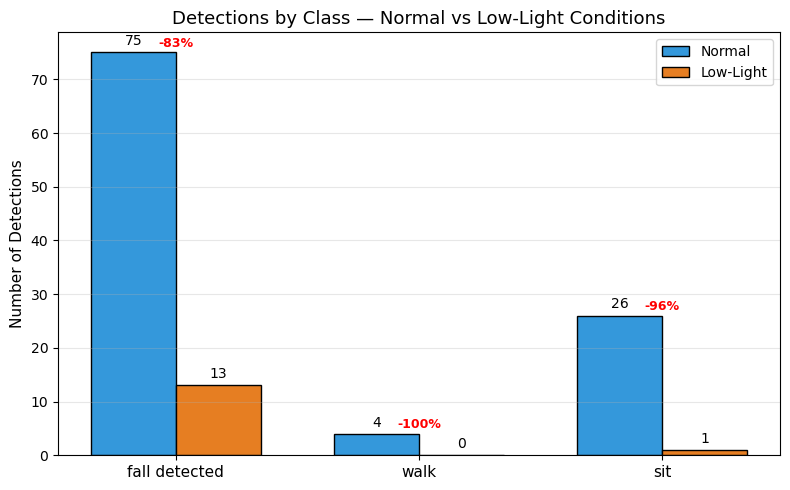

In [11]:
norm_vals = [counts_normal.get(i, 0)   for i in range(len(CLASS_NAMES))]
low_vals  = [counts_lowlight.get(i, 0) for i in range(len(CLASS_NAMES))]

x = np.arange(len(CLASS_NAMES))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x-w/2, norm_vals, w, label='Normal',    color='#3498db', edgecolor='black')
b2 = ax.bar(x+w/2, low_vals,  w, label='Low-Light', color='#e67e22', edgecolor='black')
ax.bar_label(b1, padding=3, fontsize=10)
ax.bar_label(b2, padding=3, fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('Number of Detections', fontsize=11)
ax.set_title('Detections by Class — Normal vs Low-Light Conditions', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, (n, l) in enumerate(zip(norm_vals, low_vals)):
    if n > 0:
        drop = (n - l) / n * 100
        ax.text(i, max(n, l) + 1, f'-{drop:.0f}%',
                ha='center', fontsize=9, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('test_condition_comparison.png', dpi=150)
plt.show()

---
## 11. Qualitative Results — Visualise Predictions

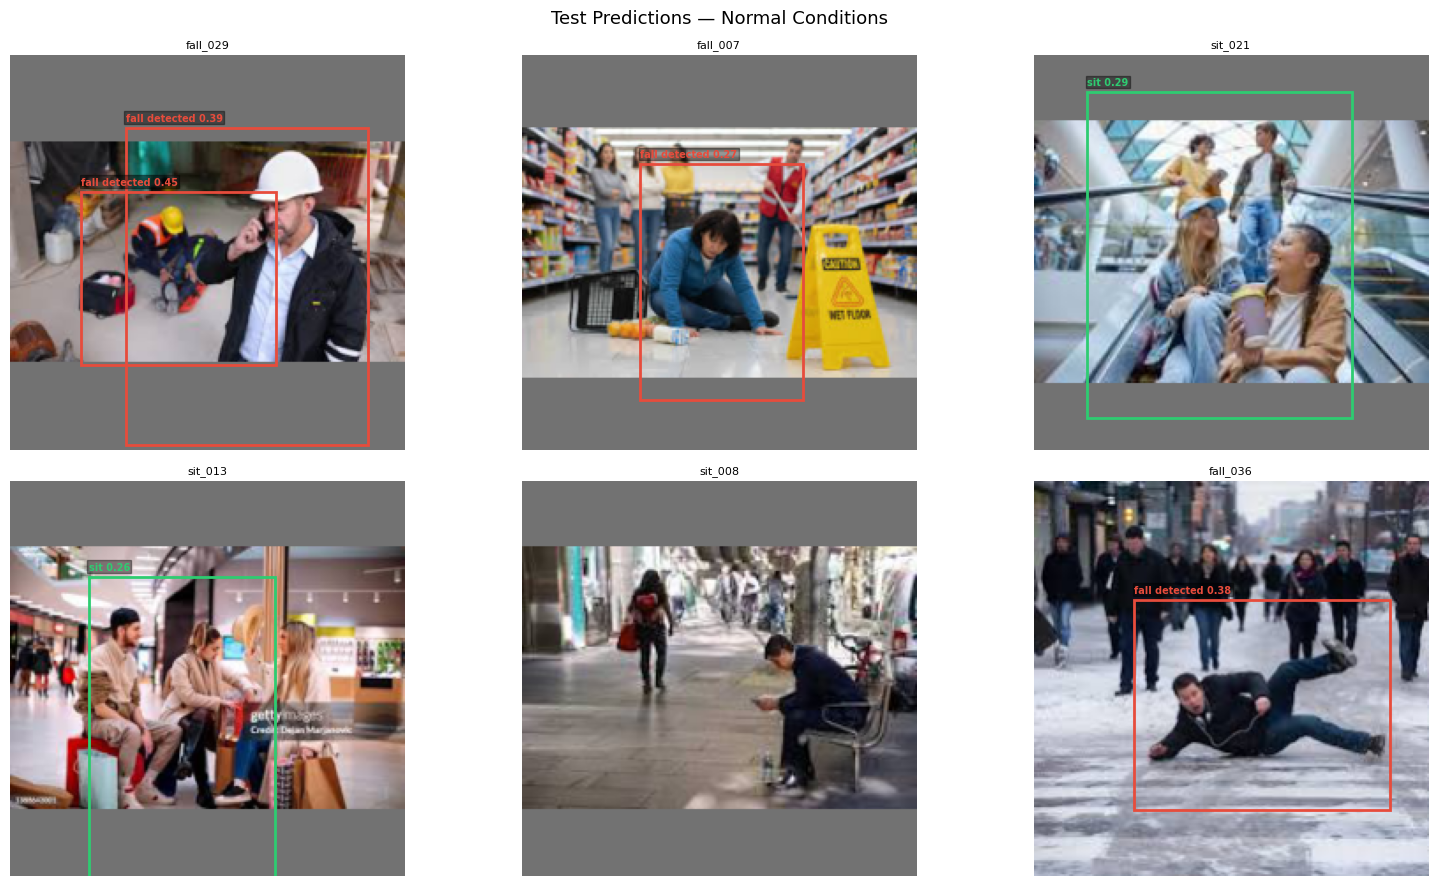

Saved: Test_Predictions_-_Normal_Conditions.png


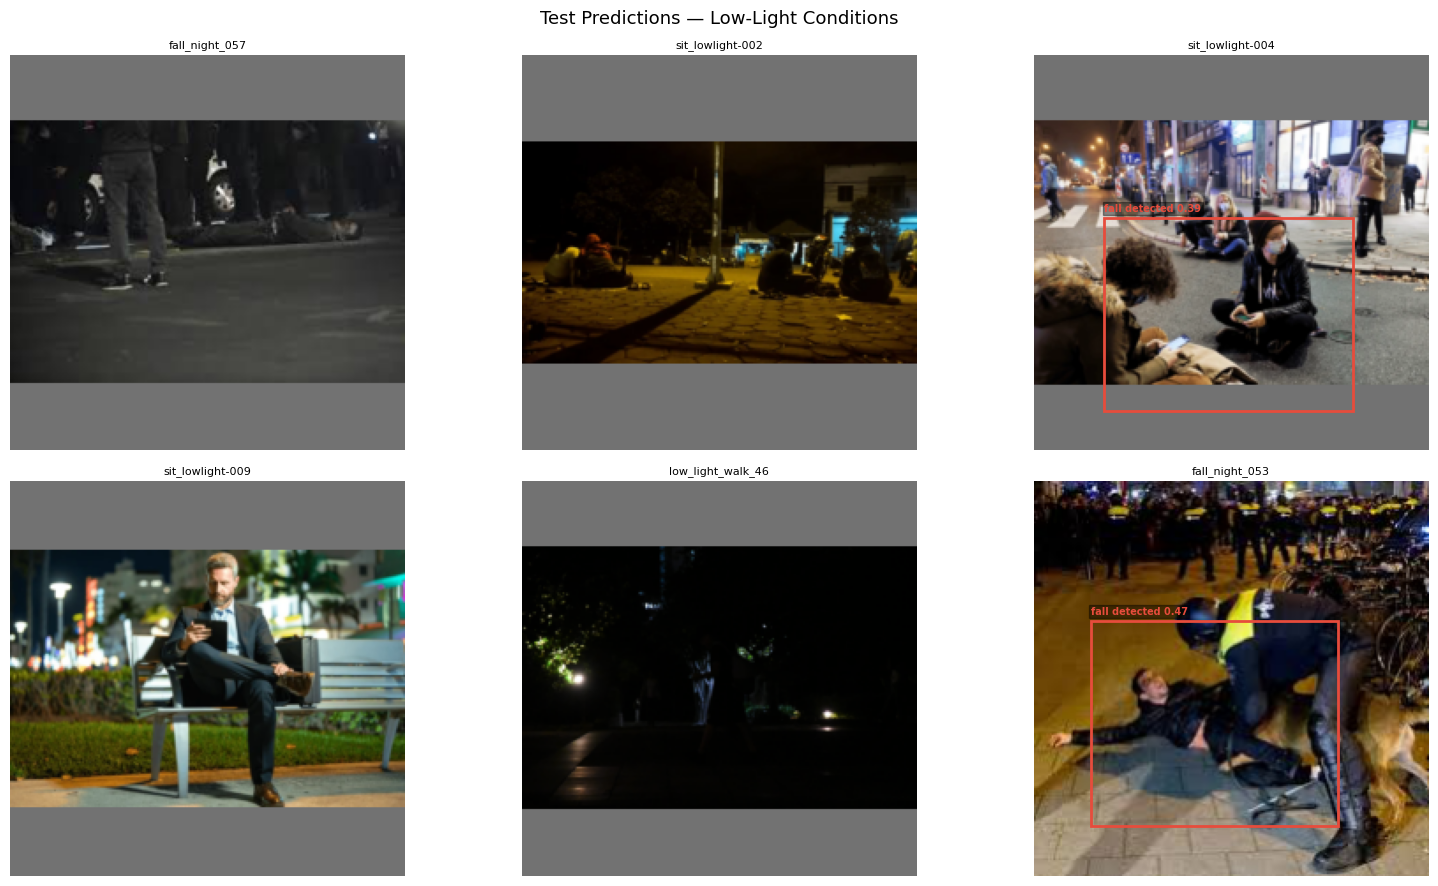

Saved: Test_Predictions_-_Low-Light_Conditions.png


In [12]:
def visualise_predictions(img_list, n=6, conf=CONF_THRESHOLD, title='Predictions'):
    """Show a grid of n random images with predicted bounding boxes."""
    if not img_list:
        print('No images to show'); return

    sample = random.sample(img_list, min(n, len(img_list)))
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    for ax, img_path in zip(axes.flatten(), sample):
        img_pil = Image.open(img_path).convert('RGB')
        lb_img  = LetterboxResize(IMG_SIZE)(img_pil)
        lW, lH  = lb_img.size
        dets    = predict_image(img_path, conf=conf)

        ax.imshow(lb_img)
        for det in dets:
            x1, y1, x2, y2 = det['box']
            name  = CLASS_NAMES[det['class']]
            color = BOX_COLORS.get(name, 'white')
            rect  = patches.Rectangle(
                (x1*lW, y1*lH), (x2-x1)*lW, (y2-y1)*lH,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1*lW, y1*lH - 4,
                    f"{name} {det['score']:.2f}",
                    color=color, fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))
        ax.set_title(img_path.stem, fontsize=8)
        ax.axis('off')

    for ax in axes.flatten()[len(sample):]:
        ax.axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    fname = title.replace(' ', '_').replace('—', '-') + '.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Saved: {fname}')


visualise_predictions(normal_imgs,   n=6, title='Test Predictions — Normal Conditions')
visualise_predictions(lowlight_imgs, n=6, title='Test Predictions — Low-Light Conditions')

---
## 12. Viewpoint & Distance Analysis

In [13]:
# ── Update prefixes to match YOUR filenames ───────────────────────────────────
VIEWPOINT_GROUPS = {
    'side_view': ('walk', 'fall_0', 'sit_0'),
    'top_down' : ('top', 'above', 'overhead'),
    'frontal'  : ('front', 'face'),
}

def group_by_prefix(img_list, groups):
    result = {k: [] for k in groups}
    result['other'] = []
    for f in img_list:
        matched = False
        for group_name, prefixes in groups.items():
            if f.stem.lower().startswith(prefixes):
                result[group_name].append(f)
                matched = True; break
        if not matched:
            result['other'].append(f)
    return result


viewpoint_groups = group_by_prefix(all_imgs, VIEWPOINT_GROUPS)
print('Viewpoint groups:')
for g, imgs in viewpoint_groups.items():
    print(f'  {g}: {len(imgs)} images')

vp_results = {}
for group_name, imgs in viewpoint_groups.items():
    if not imgs:
        continue
    counts = Counter()
    for img_path in imgs:
        for det in predict_image(img_path):
            counts[int(det['class'])] += 1
    vp_results[group_name] = counts
    total = sum(counts.values())
    print(f'[{group_name}] {len(imgs)} images → {total} detections')

Viewpoint groups:
  side_view: 151 images
  top_down: 0 images
  frontal: 0 images
  other: 32 images
[side_view] 151 images → 105 detections
[other] 32 images → 14 detections


---
## 13. Single Image Test

Image      : walk_020.jpg
Detections : 2
  [sit]  conf=0.303  box=(34,41,118,221)
  [sit]  conf=0.251  box=(99,0,187,168)


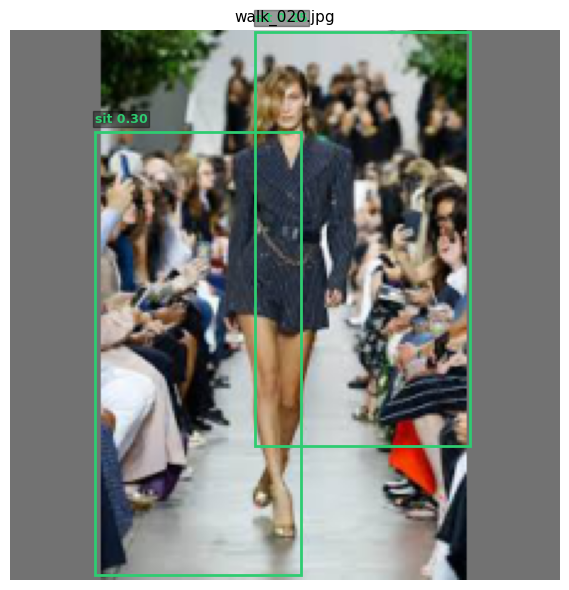

In [14]:
def test_single_image(img_path, conf=CONF_THRESHOLD):
    img_path = Path(img_path)
    assert img_path.exists(), f'Image not found: {img_path}'

    dets    = predict_image(img_path, conf=conf)
    img_pil = Image.open(img_path).convert('RGB')
    lb_img  = LetterboxResize(IMG_SIZE)(img_pil)
    lW, lH  = lb_img.size

    print(f'Image      : {img_path.name}')
    print(f'Detections : {len(dets)}')
    for det in dets:
        x1, y1, x2, y2 = det['box']
        px1 = int(x1*lW); py1 = int(y1*lH)
        px2 = int(x2*lW); py2 = int(y2*lH)
        print(f'  [{CLASS_NAMES[det["class"]]}]  '
              f'conf={det["score"]:.3f}  box=({px1},{py1},{px2},{py2})')

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(lb_img)
    for det in dets:
        x1, y1, x2, y2 = det['box']
        name  = CLASS_NAMES[det['class']]
        color = BOX_COLORS.get(name, 'white')
        rect  = patches.Rectangle(
            (x1*lW, y1*lH), (x2-x1)*lW, (y2-y1)*lH,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1*lW, y1*lH - 4,
                f"{name} {det['score']:.2f}",
                color=color, fontsize=9, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1))
    ax.set_title(img_path.name, fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Picks a random test image automatically
random_img = random.choice(all_imgs)
test_single_image(random_img)

---
## 14. Summary Table

In [15]:
summary = pd.DataFrame({
    'Class'       : CLASS_NAMES,
    'AP@50'       : [round(v, 4) for v in results['ap50']],
    'Normal Det'  : [counts_normal.get(i, 0)   for i in range(NUM_CLASSES)],
    'LowLight Det': [counts_lowlight.get(i, 0) for i in range(NUM_CLASSES)],
})
summary['Drop (%)'] = (
    (summary['Normal Det'] - summary['LowLight Det'])
    / summary['Normal Det'].replace(0, 1) * 100
).round(1)

print('='*60)
print('   ONE-STEP FCOS TEST RESULTS SUMMARY')
print('='*60)
print(f'  Overall mAP@50    : {results["mAP50"]:.4f}')
print(f'  Overall mAP@50-95 : {results["mAP5095"]:.4f}')
print(f'  Overall Precision : {results["precision"]:.4f}')
print(f'  Overall Recall    : {results["recall"]:.4f}')
print(f'  Test images       : {len(all_imgs)}')
print(f'  Normal images     : {len(normal_imgs)}')
print(f'  Low-light images  : {len(lowlight_imgs)}')
print('='*60)
print(summary.to_string(index=False))
print('='*60)

   ONE-STEP FCOS TEST RESULTS SUMMARY
  Overall mAP@50    : 0.1330
  Overall mAP@50-95 : 0.0384
  Overall Precision : 0.5210
  Overall Recall    : 0.2780
  Test images       : 183
  Normal images     : 151
  Low-light images  : 32
        Class  AP@50  Normal Det  LowLight Det  Drop (%)
fall detected 0.3336          75            13      82.7
         walk 0.0495           4             0     100.0
          sit 0.0158          26             1      96.2
